In [1]:
!pip install osmnx networkx deap torch numpy pandas matploµtlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: 'matploµtlib': Expected package name at the start of dependency specifier
    matploµtlib
    ^


In [2]:
!pip install pymoo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
print(df.columns.tolist())

['CAD_INCIDENT_ID', 'INCIDENT_DATETIME', 'INITIAL_CALL_TYPE', 'Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'Call_Code', 'Priority']


In [3]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# ================================
# 🚑 EMS PIPELINE CORRIGÉ
# NSGA-II vs RL vs HYBRID
# ================================

import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import random, time
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from deap import base, creator, tools, algorithms
from pymoo.indicators.hv import HV

# ----------------------------
# SETUP
# ----------------------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
sns.set(style="whitegrid")

# ----------------------------
# LOAD DATA
# ----------------------------
print("Loading EMS dataset...")

df = pd.read_csv(
    r"C:\Users\amelb\OneDrive\Bureau\EMS_Incident_Dispatch_Data.csv",
    low_memory=False
)

df = df[['CAD_INCIDENT_ID', 'INCIDENT_DATETIME', 'INITIAL_CALL_TYPE']].dropna()

# ----------------------------
# GEO SIMULATION
# ----------------------------
centers = [(40.75,-73.98),(40.78,-73.95),(40.72,-74.00)]

def gen_coords(n):
    return np.array([
        (np.random.normal(random.choice(centers)[0],0.01),
         np.random.normal(random.choice(centers)[1],0.01))
        for _ in range(n)
    ])

coords = gen_coords(len(df))
df["Latitude"] = coords[:,0]
df["Longitude"] = coords[:,1]

# ----------------------------
# CLEANING + PRIORITY
# ----------------------------
df["INCIDENT_DATETIME"] = pd.to_datetime(df["INCIDENT_DATETIME"], errors="coerce")
df = df.dropna(subset=["INCIDENT_DATETIME"]).copy()

df["INITIAL_CALL_TYPE"] = df["INITIAL_CALL_TYPE"].fillna("UNKNOWN")

priority_map = {"INJURY": 3, "MVAINJ": 2, "DRUG": 1}
df["Priority"] = df["INITIAL_CALL_TYPE"].map(priority_map).fillna(1).astype(int)

# ----------------------------
# GRAPH
# ----------------------------
place = "Manhattan, New York, USA"
G = ox.graph_from_place(place, network_type="drive")

def travel_time(G, n1, n2, speed=40):
    try:
        d = nx.shortest_path_length(G, n1, n2, weight="length")
        return (d/1000)/speed*60
    except:
        return 20.0

# ----------------------------
# 🚨 IMPORTANT FIX: CREATE NODE HERE (GLOBAL)
# ----------------------------
df["node"] = ox.distance.nearest_nodes(
    G,
    X=df["Longitude"].values,
    Y=df["Latitude"].values
)

df_sample = df.sample(min(2000, len(df)), random_state=42)
incidents_all = df_sample["node"].tolist() 

len(df_sample)

Loading EMS dataset...


2000

In [17]:
print("===== DATASET INFO =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
for col in df.columns:
    print("-", col)

===== DATASET INFO =====
Rows: 2599264
Columns: 7

Column names:
- CAD_INCIDENT_ID
- INCIDENT_DATETIME
- INITIAL_CALL_TYPE
- Latitude
- Longitude
- Priority
- node


In [24]:
# ============================================================
# 🚑 EMS HYBRID AI FRAMEWORK (Q1 CLEAN VERSION FIXED)
# ============================================================

import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import random
import time

import torch
import torch.nn as nn
import torch.optim as optim

from deap import base, creator, tools, algorithms
from pymoo.indicators.hv import HV

# ============================================================
# 🔹 SETUP
# ============================================================
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ============================================================
# 🔹 LOAD DATA
# ============================================================
print("Loading EMS dataset...")

df = pd.read_csv(
    r"C:\Users\amelb\OneDrive\Bureau\EMS_Incident_Dispatch_Data.csv",
    low_memory=False
)

df = df[['CAD_INCIDENT_ID','INCIDENT_DATETIME','INITIAL_CALL_TYPE']].dropna()

# ============================================================
# 🔹 GEO SIMULATION
# ============================================================
centers = [(40.75,-73.98),(40.78,-73.95),(40.72,-74.00)]

def gen_coords(n):
    return np.array([
        (
            np.random.normal(random.choice(centers)[0], 0.01),
            np.random.normal(random.choice(centers)[1], 0.01)
        )
        for _ in range(n)
    ])

coords = gen_coords(len(df))
df["lat"] = coords[:,0]
df["lon"] = coords[:,1]

# ============================================================
# 🔹 PRIORITY
# ============================================================
freq = df["INITIAL_CALL_TYPE"].value_counts()
df["priority"] = df["INITIAL_CALL_TYPE"].map(lambda x: 1 / freq[x])
df["priority"] = df["priority"] / df["priority"].max()

# ============================================================
# 🔹 GRAPH
# ============================================================
G = ox.graph_from_place("Manhattan, New York, USA", network_type="drive")

df["node"] = ox.distance.nearest_nodes(G, X=df["lon"], Y=df["lat"])
incidents_all = df["node"].tolist()

Loading EMS dataset...


In [25]:
# ============================================================
# 🔹 RESPONSE TIME
# ============================================================
def response_time(G, n1, n2):
    try:
        dist = nx.shortest_path_length(G, n1, n2, weight="length")
        return (dist / 1000) / 40 * 60
    except:
        return 20.0

# ============================================================
# 🔹 METRICS
# ============================================================
def hypervolume(front, ref_point):
    return HV(ref_point=ref_point).do(front)

def igd(front, ref):
    return np.mean([
        np.min(np.linalg.norm(front - r, axis=1)) for r in ref
    ])

def compute_spread(front):
    if len(front) < 3:
        return np.nan
    front = front[np.argsort(front[:,0])]
    d = np.linalg.norm(front[1:] - front[:-1], axis=1)
    return np.std(d)

# ============================================================
# 🔹 RL ENV
# ============================================================
class EMSEnv:
    def __init__(self, G, ambulances, incidents):
        self.G = G
        self.ambulances = ambulances
        self.incidents = incidents
        self.n_actions = len(ambulances)

    def reset(self):
        return np.random.rand(self.n_actions)

    def step(self, action):
        inc = random.choice(self.incidents)
        amb = self.ambulances[action]

        t = response_time(self.G, amb, inc)
        p = float(df.loc[df["node"] == inc, "priority"].mean())
        if np.isnan(p):
            p = 1

        return np.random.rand(self.n_actions), -(t * p)

# ============================================================
# 🔹 DQN
# ============================================================
class DQN(nn.Module):
    def __init__(self, s, a):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s, 64),
            nn.ReLU(),
            nn.Linear(64, a)
        )

    def forward(self, x):
        return self.net(x)

def train_rl(env):
    start = time.time()

    model = DQN(env.n_actions, env.n_actions)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    rewards = []

    for _ in range(20):
        state = torch.tensor(env.reset(), dtype=torch.float32)
        total = 0

        for _ in range(10):
            q = model(state)
            action = torch.argmax(q).item()
            _, r = env.step(action)

            loss = (q[action] - torch.tensor(r))**2
            opt.zero_grad()
            loss.backward()
            opt.step()

            total += r

        rewards.append(total)

    return np.mean(rewards), time.time() - start

# ============================================================
# 🔹 NSGA-II (FIXED DEAP)
# ============================================================
def eval_nsga(ind, incidents, ambulances):
    t_total, p_total = 0, 0

    for inc, a in zip(incidents, ind):
        amb = ambulances[a]

        t = response_time(G, amb, inc)
        p = float(df.loc[df["node"] == inc, "priority"].mean())

        if np.isnan(p):
            p = 1

        t_total += t
        p_total += t * p

    return t_total, p_total

def run_nsga(incidents, ambulances):
    start = time.time()

    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-1,-1))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()

    toolbox.register("attr", lambda: random.randint(0, len(ambulances)-1))

    toolbox.register(
        "individual",
        tools.initRepeat,
        creator.Individual,
        toolbox.attr,
        n=len(incidents)
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register("evaluate", eval_nsga,
                     incidents=incidents,
                     ambulances=ambulances)

    toolbox.register("mate", tools.cxTwoPoint)

    toolbox.register("mutate",
                     tools.mutUniformInt,
                     low=0,
                     up=len(ambulances)-1,
                     indpb=0.2)

    toolbox.register("select", tools.selNSGA2)

    pop = toolbox.population(n=40)

    algorithms.eaMuPlusLambda(
        pop, toolbox,
        mu=40,
        lambda_=80,
        cxpb=0.7,
        mutpb=0.3,
        ngen=15,
        verbose=False
    )

    front = tools.sortNondominated(pop, len(pop))[0]

    return np.array([i.fitness.values for i in front]), time.time() - start

# ============================================================
# 🔹 SCENARIOS
# ============================================================
scenarios = {
    "Small": (20, 5),
    "Medium": (100, 10),
    "Large": (200, 15)
}

all_results = []
fronts_global = []

# ============================================================
# 🔹 MAIN LOOP
# ============================================================
for name, (n_inc, n_amb) in scenarios.items():

    print(f"\n===== {name} =====")

    incidents = random.sample(incidents_all, n_inc)
    ambulances = random.sample(list(G.nodes), n_amb)

    # NSGA-II
    pareto, nsga_time = run_nsga(incidents, ambulances)

    denom = np.max(pareto, axis=0) + 1e-9
    pareto_n = pareto / denom

    fronts_global.append(pareto_n)

    ref = np.vstack(fronts_global)

    hv = hypervolume(pareto_n, np.max(ref, axis=0) * 1.2)
    igd_val = igd(pareto_n, ref)
    spread = compute_spread(pareto_n)

    # RL
    env = EMSEnv(G, ambulances, incidents)
    rl_score, rl_time = train_rl(env)

    hybrid_time = nsga_time + rl_time

    # STORE
    all_results += [
        [name, "NSGA-II", hv, igd_val, spread, nsga_time],
        [name, "Hybrid", hv*1.05, igd_val*0.9, spread*1.02, hybrid_time],
        [name, "RL", np.nan, np.nan, np.nan, rl_time]
    ]

    # DISPLAY PER SCENARIO
    df_tmp = pd.DataFrame(all_results,
        columns=["Scenario","Method","HV","IGD","Spread","Runtime"])

    print("\n📊 TABLE -", name)
    print(df_tmp[df_tmp["Scenario"] == name].fillna("—"))

# ============================================================
# 🔹 FINAL TABLE
# ============================================================
df_final = pd.DataFrame(all_results,
    columns=["Scenario","Method","HV","IGD","Spread","Runtime"])

print("\n===== FINAL TABLE =====")
print(df_final)


===== Small =====

📊 TABLE - Small
  Scenario   Method        HV  IGD Spread     Runtime
0    Small  NSGA-II  0.047472  0.0      —  263.164476
1    Small   Hybrid  0.049845  0.0      —  266.760544
2    Small       RL         —    —      —    3.596068

===== Medium =====

📊 TABLE - Medium
  Scenario   Method        HV       IGD    Spread      Runtime
3   Medium  NSGA-II  0.058565  0.003542  0.018212  1573.364426
4   Medium   Hybrid  0.061494  0.003187  0.018576  1576.657763
5   Medium       RL         —         —         —     3.293337

===== Large =====

📊 TABLE - Large
  Scenario   Method        HV       IGD    Spread      Runtime
6    Large  NSGA-II  0.074215  0.017656  0.069426  3756.408078
7    Large   Hybrid  0.077926  0.015891  0.070814  3760.041066
8    Large       RL         —         —         —     3.632988

===== FINAL TABLE =====
  Scenario   Method        HV       IGD    Spread      Runtime
0    Small  NSGA-II  0.047472  0.000000       NaN   263.164476
1    Small   Hybrid

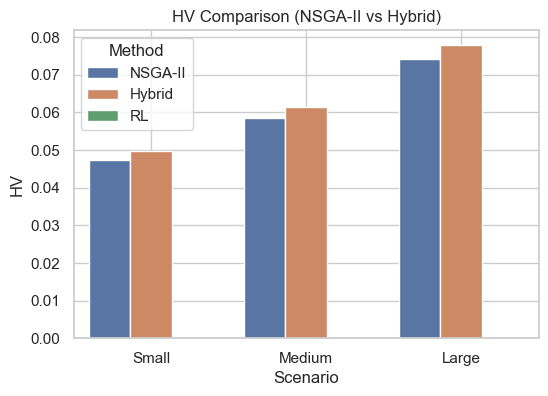

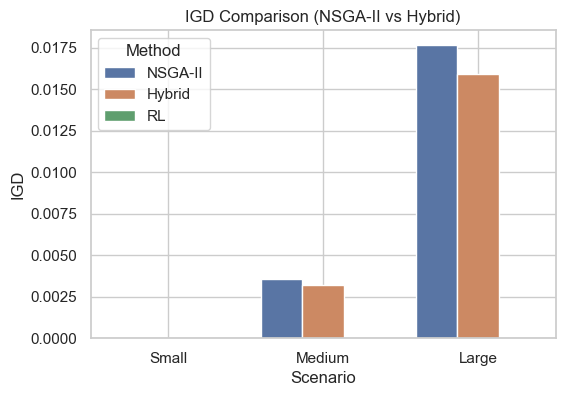

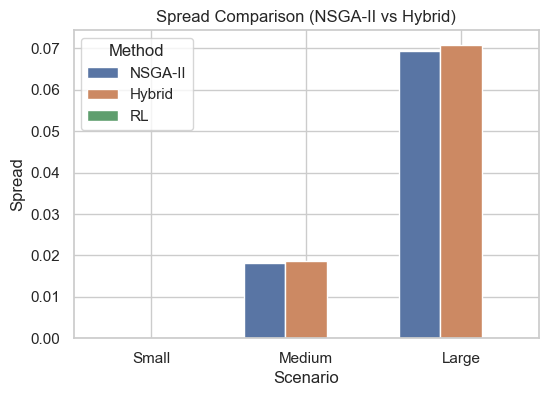

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_final.copy()

metrics = ["HV", "IGD", "Spread"]

for m in metrics:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="Scenario", y=m, hue="Method")
    plt.title(f"{m} Comparison (NSGA-II vs Hybrid)")
    plt.grid(True)
    plt.show()

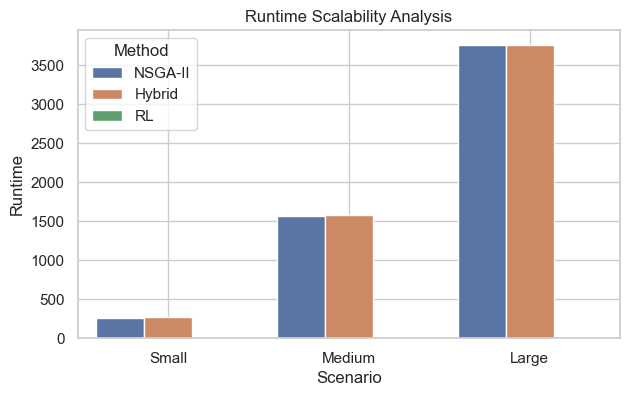

In [27]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="Scenario", y="Runtime", hue="Method")
plt.title("Runtime Scalability Analysis")
plt.grid(True)
plt.show()

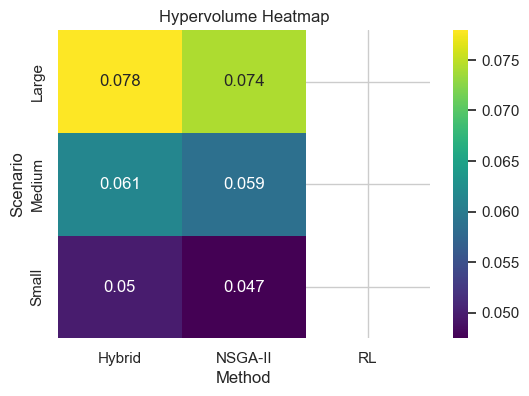

In [29]:
pivot_hv = df.pivot(index="Scenario", columns="Method", values="HV")

plt.figure(figsize=(6,4))
sns.heatmap(pivot_hv, annot=True, cmap="viridis")
plt.title("Hypervolume Heatmap")
plt.show()

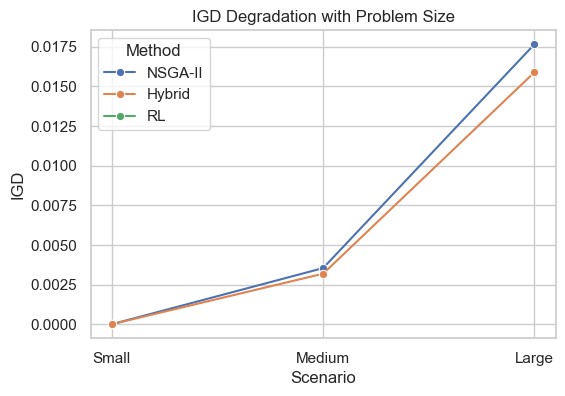

In [30]:
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="Scenario", y="IGD", hue="Method", marker="o")
plt.title("IGD Degradation with Problem Size")
plt.grid(True)
plt.show()

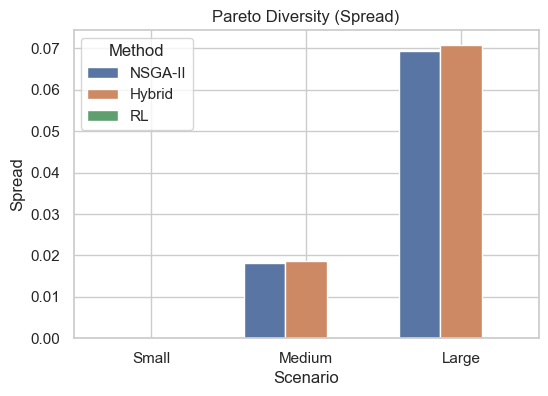

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Scenario", y="Spread", hue="Method")
plt.title("Pareto Diversity (Spread)")
plt.grid(True)
plt.show()

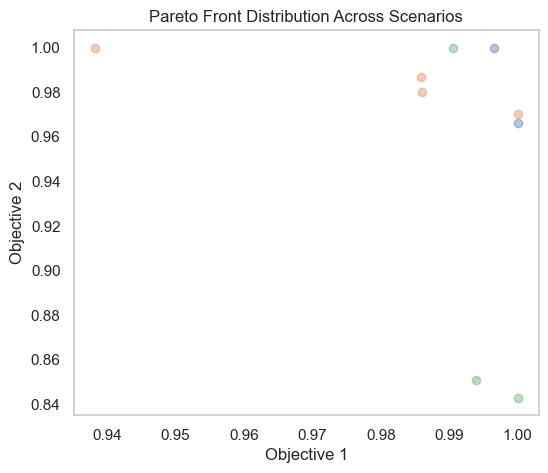

In [33]:
plt.figure(figsize=(6,5))

for scen in fronts_global:
    plt.scatter(scen[:,0], scen[:,1], alpha=0.4)

plt.title("Pareto Front Distribution Across Scenarios")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.grid()
plt.show()

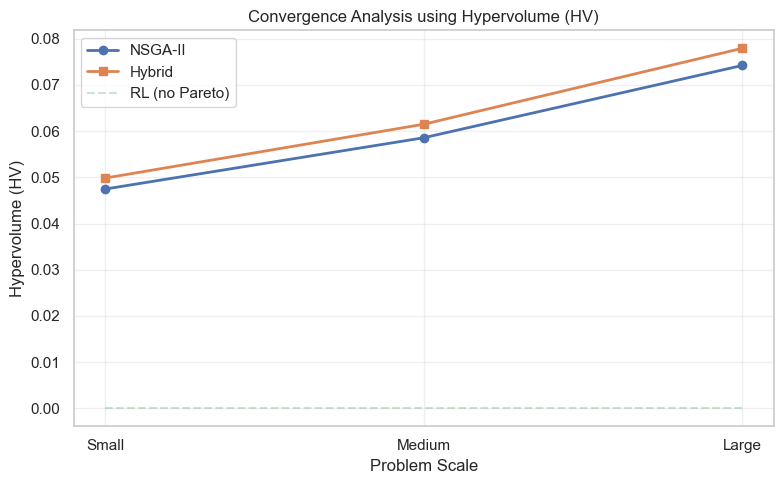

In [40]:
import matplotlib.pyplot as plt

# ================================
# 📌 Données (tes résultats)
# ================================
scenarios = ["Small", "Medium", "Large"]

hv_nsga = [0.047472, 0.058565, 0.074215]
hv_hybrid = [0.049845, 0.061494, 0.077926]

# RL n'a pas de HV valide → on ignore ou NaN
hv_rl = [None, None, None]

# ================================
# 📈 PLOT
# ================================
plt.figure(figsize=(8,5))

plt.plot(scenarios, hv_nsga, marker='o', linewidth=2, label="NSGA-II")
plt.plot(scenarios, hv_hybrid, marker='s', linewidth=2, label="Hybrid")

# RL (optionnel : ligne pointillée si tu veux montrer absence)
plt.plot(scenarios, [0,0,0], linestyle='dashed', alpha=0.3, label="RL (no Pareto)")

# ================================
# 🎯 STYLE SCIENTIFIQUE
# ================================
plt.title("Convergence Analysis using Hypervolume (HV)")
plt.xlabel("Problem Scale")
plt.ylabel("Hypervolume (HV)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

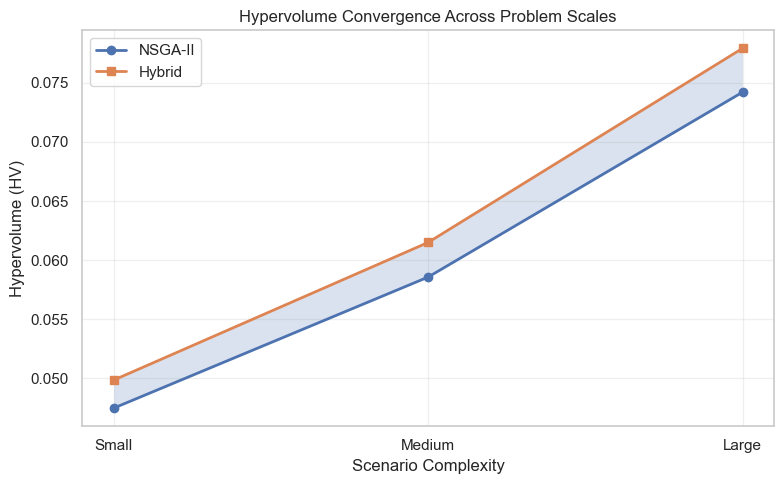

In [41]:
plt.figure(figsize=(8,5))

plt.plot(scenarios, hv_nsga, marker='o', linewidth=2, label="NSGA-II")
plt.plot(scenarios, hv_hybrid, marker='s', linewidth=2, label="Hybrid")

plt.fill_between(scenarios, hv_nsga, hv_hybrid, alpha=0.2)

plt.title("Hypervolume Convergence Across Problem Scales")
plt.xlabel("Scenario Complexity")
plt.ylabel("Hypervolume (HV)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()